# 🌦️ Weather API Test — LangGraph Mini Pipeline

**Flow:** `START → weather_tool_node → END`

**State maintained:**
- `farmer_id` — input farmer UUID
- `latitude` — fetched from `farm_fields` DB table
- `longitude` — fetched from `farm_fields` DB table
- `temperature` — today's max temperature from Open-Meteo API
- `raw_result` — full API response for inspection
- `error` — any error message

---
> ✅ **Run Cell 0 first** — it installs all required packages into the active kernel.

## Cell 0 — 📦 Install Dependencies (run once)

This installs all required packages into whichever Python kernel is currently selected.
If you're using the project `venv` kernel, packages may already be present — this is safe to re-run.

In [2]:
import sys

# Install all required packages into the active kernel
# Using -q to suppress verbose output; remove -q if you want to see install logs
packages = [
    "httpx",
    "asyncpg",
    "python-dotenv",
    "langgraph",
    "typing_extensions",
]

print(f"🐍 Kernel Python: {sys.executable}")
print(f"📦 Installing: {', '.join(packages)}\n")

import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade"] + packages,
    capture_output=True,
    text=True,
)
if result.returncode == 0:
    print("✅ All packages installed/verified successfully!")
else:
    print("❌ pip error:\n", result.stderr)

# Verify imports work
import importlib
for pkg in ["httpx", "asyncpg", "dotenv", "langgraph"]:
    try:
        importlib.import_module(pkg)
        print(f"   ✔ {pkg}")
    except ImportError:
        print(f"   ✘ {pkg} — FAILED (check errors above)")

🐍 Kernel Python: c:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe
📦 Installing: httpx, asyncpg, python-dotenv, langgraph, typing_extensions

✅ All packages installed/verified successfully!
   ✔ httpx
   ✔ asyncpg
   ✔ dotenv
   ✔ langgraph


## Cell 1 — Imports & Environment Setup

In [3]:
import os
import sys
import uuid
import json
import asyncio
import logging
from pathlib import Path
from typing import Optional
from typing_extensions import TypedDict
from contextlib import asynccontextmanager

import httpx
import asyncpg
from dotenv import load_dotenv

# ── Locate the Kisaan_backend root (one level above chatbot/) ─────────────────
# Path(__file__) doesn't work in notebooks, so we use Path.cwd() instead.
# Assumes you opened the notebook from inside the chatbot/ folder.
NOTEBOOK_DIR = Path.cwd()
# Walk up until we find the .env file
BACKEND_ROOT = NOTEBOOK_DIR
for _ in range(4):  # search up to 4 levels
    if (BACKEND_ROOT / ".env").exists():
        break
    BACKEND_ROOT = BACKEND_ROOT.parent

# Add backend root to sys.path so chatbot.* imports resolve (not needed here, but good practice)
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

# ── Load .env ─────────────────────────────────────────────────────────────────
env_path = BACKEND_ROOT / ".env"
load_dotenv(dotenv_path=env_path, override=True)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
logger = logging.getLogger("weather_test")

DATABASE_URL = os.getenv("DATABASE_URL")

print(f"📂 Notebook dir  : {NOTEBOOK_DIR}")
print(f"📂 Backend root  : {BACKEND_ROOT}")
print(f"📄 .env found    : {env_path.exists()}")
print(f"🔑 DATABASE_URL  : {'✅ SET' if DATABASE_URL else '❌ NOT FOUND — check .env!'}")

📂 Notebook dir  : e:\democopypast\Kisaan_backend\chatbot
📂 Backend root  : e:\democopypast\Kisaan_backend
📄 .env found    : True
🔑 DATABASE_URL  : ✅ SET


## Cell 2 — LangGraph State Definition

The `WeatherState` TypedDict holds everything that flows through the graph.

In [4]:
class WeatherState(TypedDict):
    """State that persists across graph nodes."""
    # ── Input ────────────────────────────────────────────────────────────
    farmer_id: str                      # UUID string supplied by caller

    # ── DB-fetched coordinates ────────────────────────────────────────────
    latitude:  Optional[float]          # center_lat from farm_fields
    longitude: Optional[float]          # center_lon from farm_fields

    # ── API result ────────────────────────────────────────────────────────
    temperature: Optional[float]        # today's max temperature (°C)
    raw_result:  Optional[dict]         # full Open-Meteo response payload

    # ── Error tracking ────────────────────────────────────────────────────
    error: Optional[str]                # human-readable error message, or None


print("✅ WeatherState TypedDict defined")
print("   Fields:", list(WeatherState.__annotations__.keys()))

✅ WeatherState TypedDict defined
   Fields: ['farmer_id', 'latitude', 'longitude', 'temperature', 'raw_result', 'error']


## Cell 3 — DB Helper

Mirrors `chatbot/db.py` — opens a fresh asyncpg connection per call (safe for Neon free tier).

In [5]:
_CONNECTION_TIMEOUT = 8  # seconds


async def _init_connection(conn: asyncpg.Connection) -> None:
    """Register JSON/JSONB codecs (mirrors chatbot/db.py)."""
    await conn.set_type_codec(
        "jsonb", encoder=json.dumps, decoder=json.loads,
        schema="pg_catalog", format="text",
    )
    await conn.set_type_codec(
        "json",  encoder=json.dumps, decoder=json.loads,
        schema="pg_catalog", format="text",
    )


@asynccontextmanager
async def get_db_connection():
    """Open a fresh asyncpg connection, yield it, then close it."""
    dsn = os.getenv("DATABASE_URL")
    if not dsn:
        raise RuntimeError("DATABASE_URL is not set")

    conn = await asyncio.wait_for(
        asyncpg.connect(dsn=dsn, timeout=_CONNECTION_TIMEOUT),
        timeout=_CONNECTION_TIMEOUT + 2,
    )
    try:
        await _init_connection(conn)
        yield conn
    finally:
        await conn.close()


print("✅ get_db_connection() helper defined")

✅ get_db_connection() helper defined


## Cell 4 — Weather Tool Node

This is the **single node** between START and END.

Steps:
1. Reads `farmer_id` from state
2. Queries `farm_fields` → populates `latitude`, `longitude` into state
3. Calls Open-Meteo API → populates `temperature`, `raw_result` into state

In [6]:
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"


async def weather_tool_node(state: WeatherState) -> WeatherState:
    """
    LangGraph node: fetches farm coordinates from DB, then calls Open-Meteo.
    Returns updated state with latitude, longitude, temperature, raw_result.
    """
    print("\n🟡 [weather_tool_node] — Entered node")

    # ── Step 1: Validate farmer_id ─────────────────────────────────────────────
    try:
        farmer_uuid = uuid.UUID(str(state["farmer_id"]))
        print(f"   farmer_uuid : {farmer_uuid}")
    except (ValueError, AttributeError) as exc:
        print(f"   ❌ Invalid UUID: {exc}")
        return {**state, "error": f"Invalid farmer_id: {state['farmer_id']}"}

    # ── Step 2: Fetch lat/lon from farm_fields ─────────────────────────────────
    print("   📡 Querying farm_fields table…")
    try:
        async with get_db_connection() as conn:
            farm = await conn.fetchrow(
                """
                SELECT center_lat, center_lon, city_name, state_name
                FROM   farm_fields
                WHERE  farmer_id = $1
                ORDER  BY created_at DESC
                LIMIT  1
                """,
                farmer_uuid,
            )
    except Exception as exc:
        msg = f"DB error: {exc}"
        print(f"   ❌ {msg}")
        return {**state, "error": msg}

    if not farm:
        msg = "No farm_fields record found for this farmer_id"
        print(f"   ❌ {msg}")
        return {**state, "error": msg}

    lat        = farm["center_lat"]
    lon        = farm["center_lon"]
    city       = farm.get("city_name")  or ""
    state_name = farm.get("state_name") or ""
    location   = f"{city}, {state_name}".strip(", ") or f"{lat:.4f}, {lon:.4f}"

    print(f"   ✅ DB result  → lat={lat}, lon={lon}, location='{location}'")

    if lat is None or lon is None:
        msg = "center_lat / center_lon are NULL in farm_fields"
        print(f"   ❌ {msg}")
        return {**state, "latitude": lat, "longitude": lon, "error": msg}

    # ── Step 3: Call Open-Meteo API ────────────────────────────────────────────
    print(f"   🌐 Calling Open-Meteo for ({lat}, {lon})…")
    try:
        async with httpx.AsyncClient(timeout=15) as client:
            resp = await client.get(
                OPEN_METEO_URL,
                params={
                    "latitude":  lat,
                    "longitude": lon,
                    "daily": (
                        "temperature_2m_max,"
                        "temperature_2m_min,"
                        "precipitation_sum,"
                        "precipitation_probability_max,"
                        "windspeed_10m_max"
                    ),
                    "forecast_days": 3,
                    "timezone": "Asia/Kolkata",
                },
            )
    except Exception as exc:
        msg = f"Open-Meteo network error: {exc}"
        print(f"   ❌ {msg}")
        return {**state, "latitude": lat, "longitude": lon, "error": msg}

    if resp.status_code != 200:
        msg = f"Open-Meteo HTTP {resp.status_code}: {resp.text[:200]}"
        print(f"   ❌ {msg}")
        return {**state, "latitude": lat, "longitude": lon, "error": msg}

    data     = resp.json()
    daily    = data.get("daily", {})
    temp_max = daily.get("temperature_2m_max", [])

    today_temp = round(temp_max[0], 1) if temp_max else None
    print(f"   ✅ Open-Meteo → today max temp = {today_temp}°C")

    return {
        **state,
        "latitude":    lat,
        "longitude":   lon,
        "temperature": today_temp,
        "raw_result":  data,
        "error":       None,
    }


print("✅ weather_tool_node() defined")

✅ weather_tool_node() defined


## Cell 5 — Build the LangGraph

```
START
  │
  ▼
weather_tool_node
  │
  ▼
 END
```

In [7]:
from langgraph.graph import StateGraph, START, END

# ── Build graph ────────────────────────────────────────────────────────────────
builder = StateGraph(WeatherState)

# Register the single node
builder.add_node("weather_tool_node", weather_tool_node)

# Connect edges:  START → weather_tool_node → END
builder.add_edge(START, "weather_tool_node")
builder.add_edge("weather_tool_node", END)

# Compile
graph = builder.compile()

print("✅ LangGraph compiled")
print("   Nodes :", list(graph.get_graph().nodes.keys()))
print("   Edges :", [(e.source, e.target) for e in graph.get_graph().edges])

✅ LangGraph compiled
   Nodes : ['__start__', 'weather_tool_node', '__end__']
   Edges : [('__start__', 'weather_tool_node'), ('weather_tool_node', '__end__')]


## Cell 6 — (Optional) Visualise the Graph

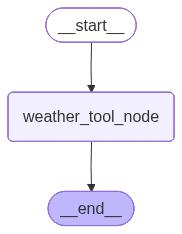

In [8]:
try:
    from IPython.display import Image, display
    img_bytes = graph.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f"⚠️  Graph visualisation skipped ({e}).")
    print("   Install pillow + playwright to enable: pip install pillow playwright && playwright install chromium")

## Cell 7 — ⚙️ Set Your Farmer ID Here

Replace the UUID below with a real `farmer_id` from your `farm_fields` table.

**Quick lookup SQL:**
```sql
SELECT farmer_id, city_name, state_name, center_lat, center_lon
FROM farm_fields
LIMIT 5;
```

In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  👇  CHANGE THIS to a real farmer_id from your DB              ║
# ╚══════════════════════════════════════════════════════════════════╝
FARMER_ID = "30156622-0b76-43e6-8eef-33bb6f7eae0c"   # ← replace with real UUID

print(f"📌 Will test with farmer_id = {FARMER_ID}")

📌 Will test with farmer_id = 30156622-0b76-43e6-8eef-33bb6f7eae0c


## Cell 8 — 🚀 Run the Graph

In [10]:
# Initial state — only farmer_id is set; everything else starts as None
initial_state: WeatherState = {
    "farmer_id":   FARMER_ID,
    "latitude":    None,
    "longitude":   None,
    "temperature": None,
    "raw_result":  None,
    "error":       None,
}

print("🚀 Invoking LangGraph…\n")

# Jupyter already runs an event loop, so use 'await' directly.
# If you get 'RuntimeError: This event loop is already running',
# install nest_asyncio:  pip install nest_asyncio
# and uncomment the two lines below:
# import nest_asyncio; nest_asyncio.apply()

result = await graph.ainvoke(initial_state)

print("\n🏁 Graph finished.")

🚀 Invoking LangGraph…


🟡 [weather_tool_node] — Entered node
   farmer_uuid : 30156622-0b76-43e6-8eef-33bb6f7eae0c
   📡 Querying farm_fields table…
   ✅ DB result  → lat=30.735, lon=76.785, location='Chandigarh, Chandigarh'
   🌐 Calling Open-Meteo for (30.735, 76.785)…


INFO | httpx | HTTP Request: GET https://api.open-meteo.com/v1/forecast?latitude=30.735&longitude=76.785&daily=temperature_2m_max%2Ctemperature_2m_min%2Cprecipitation_sum%2Cprecipitation_probability_max%2Cwindspeed_10m_max&forecast_days=3&timezone=Asia%2FKolkata "HTTP/1.1 200 OK"


   ✅ Open-Meteo → today max temp = 39.6°C

🏁 Graph finished.


## Cell 9 — 📊 Inspect Final State

In [11]:
print("═" * 55)
print("  FINAL STATE SUMMARY")
print("═" * 55)
print(f"  farmer_id   : {result.get('farmer_id')}")
print(f"  latitude    : {result.get('latitude')}")
print(f"  longitude   : {result.get('longitude')}")
print(f"  temperature : {result.get('temperature')} °C  (today max)")
print(f"  error       : {result.get('error')}")
print("═" * 55)

if result.get("error"):
    print("\n❌ TEST FAILED — see error above")
else:
    print("\n✅ TEST PASSED — weather API is working correctly!")

═══════════════════════════════════════════════════════
  FINAL STATE SUMMARY
═══════════════════════════════════════════════════════
  farmer_id   : 30156622-0b76-43e6-8eef-33bb6f7eae0c
  latitude    : 30.735
  longitude   : 76.785
  temperature : 39.6 °C  (today max)
  error       : None
═══════════════════════════════════════════════════════

✅ TEST PASSED — weather API is working correctly!


## Cell 10 — 📋 Full 3-Day Forecast

In [12]:
raw = result.get("raw_result")
if not raw:
    print("⚠️  No raw_result in state (API was not called or failed).")
else:
    daily       = raw.get("daily", {})
    dates       = daily.get("time", [])
    temp_max    = daily.get("temperature_2m_max", [])
    temp_min    = daily.get("temperature_2m_min", [])
    precip      = daily.get("precipitation_sum", [])
    precip_prob = daily.get("precipitation_probability_max", [])
    wind        = daily.get("windspeed_10m_max", [])

    print(f"{'Date':<12} {'Max°C':>6} {'Min°C':>6} {'Rain mm':>8} {'Rain%':>6} {'Wind km/h':>10}")
    print("-" * 55)
    for i, date in enumerate(dates):
        print(
            f"{date:<12} "
            f"{str(round(temp_max[i],1) if i < len(temp_max) else '-'):>6} "
            f"{str(round(temp_min[i],1) if i < len(temp_min) else '-'):>6} "
            f"{str(round(precip[i] or 0, 1) if i < len(precip) else '-'):>8} "
            f"{str(precip_prob[i] if i < len(precip_prob) else '-'):>6} "
            f"{str(round(wind[i], 1) if i < len(wind) else '-'):>10}"
        )
    print()

    total_rain = sum(precip[i] or 0 for i in range(len(precip)))
    if total_rain >= 20:
        advice = "🌧️  Hold irrigation — good rain coming!"
    elif total_rain >= 8:
        advice = "🌦️  Reduce irrigation — some rain expected."
    else:
        advice = "☀️  Irrigate your crops — no significant rain."

    print(f"  Total rain next 3 days : {round(total_rain, 1)} mm")
    print(f"  Irrigation advice      : {advice}")

Date          Max°C  Min°C  Rain mm  Rain%  Wind km/h
-------------------------------------------------------
2026-04-24     39.6   24.1        0      3       12.4
2026-04-25     40.0   24.8        0      0       15.6
2026-04-26     39.8   22.5        0      0       16.2

  Total rain next 3 days : 0 mm
  Irrigation advice      : ☀️  Irrigate your crops — no significant rain.


## Cell 11 — 🔍 Raw JSON Response

In [13]:
raw = result.get("raw_result")
if raw:
    print(json.dumps(raw, indent=2))
else:
    print("No raw API response available.")

{
  "latitude": 30.75,
  "longitude": 76.75,
  "generationtime_ms": 0.0661611557006836,
  "utc_offset_seconds": 19800,
  "timezone": "Asia/Kolkata",
  "timezone_abbreviation": "GMT+5:30",
  "elevation": 348.0,
  "daily_units": {
    "time": "iso8601",
    "temperature_2m_max": "\u00b0C",
    "temperature_2m_min": "\u00b0C",
    "precipitation_sum": "mm",
    "precipitation_probability_max": "%",
    "windspeed_10m_max": "km/h"
  },
  "daily": {
    "time": [
      "2026-04-24",
      "2026-04-25",
      "2026-04-26"
    ],
    "temperature_2m_max": [
      39.6,
      40.0,
      39.8
    ],
    "temperature_2m_min": [
      24.1,
      24.8,
      22.5
    ],
    "precipitation_sum": [
      0.0,
      0.0,
      0.0
    ],
    "precipitation_probability_max": [
      3,
      0,
      0
    ],
    "windspeed_10m_max": [
      12.4,
      15.6,
      16.2
    ]
  }
}
